# Prepare the Data

## The Model Sand Dataset Stucture from teh training

In [1]:
from Sentence_Models import *

## The Settings

In [2]:
import torch
import os
if torch.cuda.is_available():
    #### Run on Gogle Colab
    # !pip install torch-ort
    # !python -m torch_ort.configure
    !python -m pip install lightning
    !python -m pip install transformers
    pin_memory = False
    num_workers = os.cpu_count() - 2 if os.cpu_count() -2 > 3 else 3

    device = torch.device("cuda")
    accelerator = "gpu"


    from google.colab import drive
    drive.mount('/content/drive')
    data_dir = "/content/drive/MyDrive/Colab Data/RetrievalModel"
    # root_dir = "./drive/MyDrive/Colab Data/ResidualNeuralNetwork"
    torch.cuda.memory.empty_cache()
else:
    ### Run on my personal tower
    device = torch.device("cpu")
    accelerator = "cpu"
    data_dir = "EmbeddedData"
    # root_dir = "."


torch.set_float32_matmul_precision("medium")

## Build the Dataloader for pytorch_lighnign test

In [3]:
import numpy as np
import pandas as pd

Large_Dataset = pd.read_parquet(f"{data_dir}/SentenceEmbedding.parquet")


from sklearn import preprocessing
le = preprocessing.LabelEncoder()
targets = le.fit_transform(Large_Dataset.esci_label.to_numpy())
Large_Dataset["esci_label_encoded"] = targets

labels, class_counts = np.unique(Large_Dataset.esci_label, return_counts = True)
total_samples = len(Large_Dataset.esci_label)
num_classes = len(class_counts)
class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights / np.sum(class_weights)).type(torch.float)

encoding_to_label_dict = {encoding: label for encoding, label in enumerate(labels)}

Large_Dataset_Test = Large_Dataset.loc[Large_Dataset.split == "test", :].drop(columns = [("split", "")])

SentenceEmbedding_Test = Dataset_SentenceEmbedding(Large_Dataset_Test)
batch_size = 256#  if torch.cuda.is_available() else 16

if torch.cuda.is_available():
    SentenceEmbedding_Test = DataLoader(SentenceEmbedding_Test, batch_size = batch_size, shuffle = False, pin_memory=pin_memory)
else:
    SentenceEmbedding_Test = DataLoader(SentenceEmbedding_Test, batch_size = batch_size, shuffle = False, pin_memory=False)

In [4]:
Large_Dataset_Test

product_title                                                       \
                    0          1         2          3         4          5   
104         19.782125 -20.849241  6.912220   8.974546  2.222180  12.317185   
105         19.782125 -20.849241  6.912220   8.974546  2.222180  12.317185   
106         13.794383 -19.057865  6.026787   3.129192  1.971212  11.096588   
107          3.686759  -6.699598  0.070188  16.677197  0.953404  -3.212091   
108         -4.444930  -6.306578 -4.463382   2.366049  2.559024  -0.128045   
...               ...        ...       ...        ...       ...        ...   
2621265     -0.443321  -0.105362 -2.251524   1.220237 -2.371012   3.012539   
2621268     -0.443321  -0.105362 -2.251524   1.220237 -2.371012   3.012539   
2621270      5.173185   1.389299 -2.997925  -0.967095 -2.599024   0.944685   
2621278      4.172548   3.149167 -3.231992  -1.331784 -4.331998   2.759795   
2621281      8.065278   1.549434  3.355032   0.045489 -1.441577   0.319186   

                                                   ...      query            \
                6          7         8          9  ...         27        28   
104     -7.601524  -3.177181 -1.730943  15.464297  ...   0.245681  0.478157   
105     -7.601524  -3.177181 -1.730943  15.464297  ...   0.245681  0.478157   
106      2.430388  -1.220207 -1.616536   6.775422  ...   0.245681  0.478157   
107     -5.474694 -17.425945  3.558507   4.311421  ...   0.245681  0.478157   
108      4.757328  -0.157374  1.542249   4.062286  ...   0.245681  0.478157   
...           ...        ...       ...        ...  ...        ...       ...   
2621265 -0.654934  -1.202141 -1.207664   3.896080  ...  12.286843  0.417928   
2621268 -0.654934  -1.202141 -1.207664   3.896080  ...  17.368092 -2.015461   
2621270  1.534002  -2.275209  1.074231   0.902044  ...  12.286843  0.417928   
2621278 -1.922912  -3.856732  0.285753   2.141151  ...  12.286843  0.417928   
2621281  1.120990  -2.574990  1.054582   2.441575  ...  12.286843  0.417928   

                                        product_id query_id example_id  \
               29        30         31                                   
104     -6.215600  0.982598  -3.607609  1471182312     5814     138480   
105     -6.215600  0.982598  -3.607609  1534451560     5814     138479   
106     -6.215600  0.982598  -3.607609  1644730162     5814     138478   
107     -6.215600  0.982598  -3.607609  3423762527     5814     138477   
108     -6.215600  0.982598  -3.607609  8408205382     5814     138475   
...           ...       ...        ...         ...      ...        ...   
2621265 -5.427651  2.903483  -4.058306  B0971WCFX6   122894    2426512   
2621268  3.294846  6.958182 -10.898798  B0971WCFX6   129053    2580205   
2621270 -5.427651  2.903483  -4.058306  B09B3L32WL   122894    2426514   
2621278 -5.427651  2.903483  -4.058306  B09FJYBVKS   122894    2426515   
2621281 -5.427651  2.903483  -4.058306  B09FTJ3S1N   122894    2426516   

        esci_label esci_label_encoded  
                                       
104              E                  1  
105              E                  1  
106              E                  1  
107              S                  3  
108              S                  3  
...            ...                ...  
2621265          S                  3  
2621268          S                  3  
2621270          E                  1  
2621278          E                  1  
2621281          S                  3  

[638016 rows x 229 columns]

# Load the original Data

In [5]:
import numpy as np
import pandas as pd

device = torch.device("cpu")
accelerator = "cpu"
data_dir = "esci-data/shopping_queries_dataset"

Products = pd.read_parquet(f"{data_dir}/shopping_queries_dataset_products.parquet").fillna("")
Products.loc[Products.product_color == "Negro (", "product_color"] = "Negro"
Queries = pd.read_parquet(f"{data_dir}/shopping_queries_dataset_examples.parquet").fillna("").drop_duplicates(subset = "query_id")
# Dataset = pd.merge(Products, Examples, on = ["product_id", "product_locale"]).drop_duplicates()
# Dataset.head()

In [6]:
Queries

,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split
0,0,revent 80 cfm,0,B000MOO21W,us,I,0,1,train
16,16,!awnmower tires without rims,1,B075SCHMPY,us,I,1,1,train
32,32,!qscreen fence without holes,2,B07D7TBSGH,us,I,1,1,test
70,70,!solid camiseta sin manga,3,B08TQH4RBB,es,E,1,1,train
109,109,"""vitamina c""",4,B088X4B517,es,E,0,1,test
...,...,...,...,...,...,...,...,...,...
2621208,2621208,ﾎﾙｽﾀｰ,130647,B0756RZY5R,jp,E,0,1,test
2621224,2621224,ﾏｼﾞｯｸﾘﾝ,130648,B07CNF6HMT,jp,E,0,1,train
2621240,2621240,ﾒｽﾃｨﾝ,130649,B088QJ34Q1,jp,E,1,1,train
2621256,2621256,ﾚﾃﾞｨｰｽ水着,130650,B0892WRNZC,jp,E,0,1,train


In [7]:
Products

,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale
0,B079VKKJN7,"11 Degrees de los Hombres Playera con Logo, Ne...",Esta playera con el logo de la marca Carrier d...,11 Degrees Negro Playera con logo\nA estrenar ...,11 Degrees,Negro,es
1,B079Y9VRKS,Camiseta Eleven Degrees Core TS White (M),,,11 Degrees,Blanco,es
2,B07DP4LM9H,11 Degrees de los Hombres Core Pull Over Hoodi...,La sudadera con capucha Core Pull Over de 11 G...,11 Degrees Azul Core Pull Over Hoodie\nA estre...,11 Degrees,Azul,es
3,B07G37B9HP,11 Degrees Poli Panel Track Pant XL Black,,,11 Degrees,,es
4,B07LCTGDHY,11 Degrees Gorra Trucker Negro OSFA (Talla úni...,,,11 Degrees,Negro,es
...,...,...,...,...,...,...,...
1814919,B09FJYBVKS,スポーツブラ 揺れない ヨガウェア レディース トップス 通気性 ナイトブラ スポーツブラジ...,<p>【注意事項】</p><p>※商品内容以外のアクセサリー・小物等は付属しません.</p>...,シンプルのデザインで合わせやすいです。コート、半袖、シャツを合わせて、家で着てもいい、寝てい...,Doworspaw,ベージュ,jp
1814920,B09FTJ3S1N,ブラジャー レディース 補正ブラ Gabrioir 揺れない 大きいサイズ バストアップ美胸...,<p>【配送】</p><p>普通には2-3日後出荷できますが。出荷した後15-25日ぐらい届...,【いろんな場合に適用】軽い運動時、家事、外出、長時間移動、温泉旅行などに活用なセクシルームブ...,Gabrioir,パープル,jp
1814921,B09G72LDQZ,レディース ブラジャー 補正ブラ トップス Gabrioir 大きいサイズ 揺れない 脇高設...,<p>【配送】</p><p>普通には2-3日後出荷できますが。出荷した後15-25日ぐらい届...,【いろんな場合に適用】軽い運動時、家事、外出、長時間移動、温泉旅行などに活用なセクシルームブ...,Gabrioir,ベージュ,jp
1814922,B09GBGRTPB,ナイトブラ ノンワイヤーブラ ブラジャー レディース Gabrioir 大きいサイズ パット...,<p>【配送】</p><p>普通には2-3日後出荷できますが。出荷した後15-25日ぐらい届...,【いろんな場合に適用】軽い運動時、家事、外出、長時間移動、温泉旅行などに活用なセクシルームブ...,Gabrioir,パープル,jp


## Expand the Model to perform the tasks and tests

In [8]:
from annoy import AnnoyIndex
import copy
from tqdm import tqdm

class Tasks(Retrieval_Lightning):
    """
    Extendsion of the lightnig_class to handle the example tasks
    """
    def __init__(self, out_nodes, weights, device, num_classes, hp):
        super().__init__(out_nodes, weights, device, num_classes, hp)
        

    def predict(self, query, product):
        with torch.no_grad():
            query = self.query_tower(query)
            product = self.product_tower(product)
            # esci_onehot = self.onehot(esci_labels_encoded)
    
            # Cosine_Similarity goes from -1 (vectors completly opposite directions) to 1 (vectors are identical)
            # As I want to use the Similarity as a probability of how well the product matches the query, any similarity smaller than 0 is set to 0.
            Similarity = self.cosine_similarity(product, query)
            Prediction = torch.argmax(self.sim_to_class(Similarity), dim = 1)
            return Prediction
        
    
    def Estimate_Esci_Label(self, x):
        """
        Use with pd.Series.apply on the 'Estimated Score' column
        """
        return encoding_to_label_dict[x]
  

    def Task(self, subset):
        """
        Task 1 - Query-Product Ranking:
        Given a user specified query and a list of matched products, the goal of this task is to rank the products so that the relevant products are ranked above the non-relevant one
        
        Task 2 - Multi-class Product Classification: 
        Given a query and a result list of products retrieved for this query, the goal of this task is to classify each product as being an Exact, Substitute, Complement, or Irrelevant match for the query.
        """

        """
        Task 3 - Product Substitute Identification: 
        This task will measure the ability of the systems to identify the substitute products in the list of results for a given query.
        """
        products = torch.tensor(subset.iloc[:, :6*tensor_size].to_numpy())
        query = torch.tensor(subset.iloc[:, 6*tensor_size:7*tensor_size].to_numpy())# .repeat(products.shape[0])
        esci_label_encoded = subset.loc[:, ("esci_label_encoded", "")].to_numpy()[:, None]
        esci_label = subset.loc[:, "esci_label"].to_numpy()[:, None]
        product_id = subset.loc[:, "product_id"].to_numpy()[:, None]
        
        predicted_label_encoded = self.predict(query, products).numpy()[:, None]

        Result_matrix = np.concatenate(
            (product_id,
             esci_label,
             esci_label_encoded,
             predicted_label_encoded,
            ), axis = 1)
        Result_df = pd.DataFrame(Result_matrix,columns = ["Prodcut_ID", "True Esci Label", "True Encoding", "Predicted Encoding"]).sort_values(by = ["True Encoding"], ascending = [True]) # I want three columns
        Result_df["Predicted Esci Label"] = Result_df["Predicted Encoding"].apply(lambda x: self.Estimate_Esci_Label(x))
        # Result_df = Result_df.loc[:, ("Prodcut_ID", "Estimated Esci Label", "True Esci Label", "Estimated Score", "True Score")]
        return Result_df

    def Task3(self, subset):
        """
        Task 3 - Product Substitute Identification: 
        This task will measure the ability of the systems to identify the substitute products in the list of results for a given query.
        """
        Result_df = self.Task1_Task2(subset)
        substitute_mask = Result_df["True Esci Label"] == "S"
        Result_df = Result_df.loc[substitute_mask, :]
        Result_df = Result_df.sort_values(by = ["Predicted Encoding"], ascending = False)
        return Result_df

    # def build_preemptive_distance_tree(self, products_embedded, embedding_length = 256):
    #     """
    #     Build a euclidean distance tree with all the embedded products
    #     """
    #     AnnoyTree = AnnoyIndex(embedding_length, "euclidean")
        
    #     with torch.no_grad():
    #         for i in tqdm(range(products_embedded.shape[0]), desc = "putting all products into the tree"):
    #             current_product_embedded = torch.tensor(products_embedded.iloc[i, :].to_numpy(), dtype = torch.float32)
    #             current_product_embedded_after_tower = self.product_tower(current_product_embedded[None, :])
    #             AnnoyTree.add_item(i, current_product_embedded_after_tower.flatten())

    #     return AnnoyTree

    # def get_neighbours_of_query(self, tree, query, query_id_for_tree, embedding_length = 256, neighbours = 10):
    #     "Create a copy of the almost-build tree, finish it with the current query and get the tree ids of the 10 closest products"
    #     CopyTree = copy.deepcopy(tree)
    #     query_for_tree = self.query_tower(torch.tensor(query.to_numpy(), dtype = torch.float32)[None, :])
    #     CopyTree.add_item(query_id_for_tree, query_for_tree.flatten())
    #     CopyTree.build(50)
    #     neighbour_ids = CopyTree.get_nns_by_item(query_id_for_tree, n = neighbours + 1)
    #     return neighbour_ids

    

# Perform the Tasks

## Load the Best Training CHeckpoint

In [9]:
import numpy as np

hp = Hyperparameters()
modelname = "retrieval_model"
try:
    del Model
except:
    None
finally:
    Model = Tasks.load_from_checkpoint(f"{hp.bestmodel_BasePath}/{modelname}/BestModel.save", out_nodes = batch_size, weights = class_weights, device = device, num_classes = num_classes, hp = hp)
    Model.eval() # no trainign anymore, switch to eval mode

## The tasks

Query ID: 65947


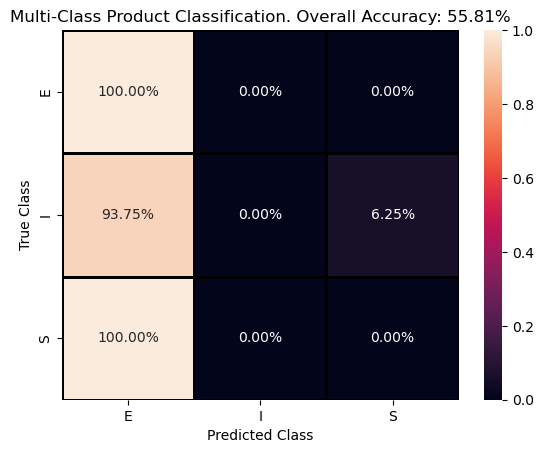

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
| 36 | B08BPLH6BZ   | S                 |               3 |                    1 | E                      |
| 10 | B01G3ZMXF0   | S                 |               3 |                    1 | E                      |
|  3 | B0068NBY62   | S                 |               3 |                    1 | E                      |
+----+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------

Query ID: 7581


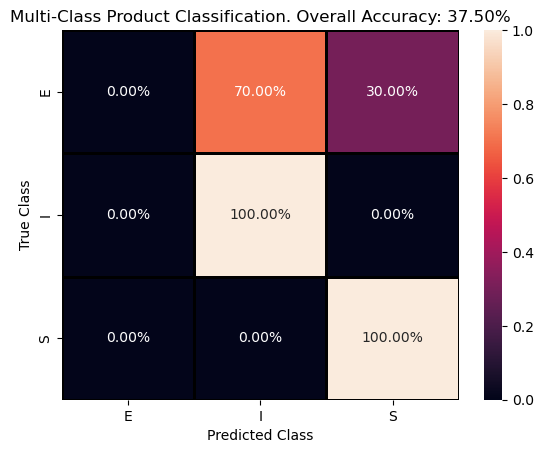

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
| 12 | B07XSRVBKN   | S                 |               3 |                    3 | S                      |
| 13 | B003BF21PS   | S                 |               3 |                    3 | S                      |
+----+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------

Query ID: 12802


C:\Users\flash\AppData\Local\Temp\ipykernel_10780\917970735.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


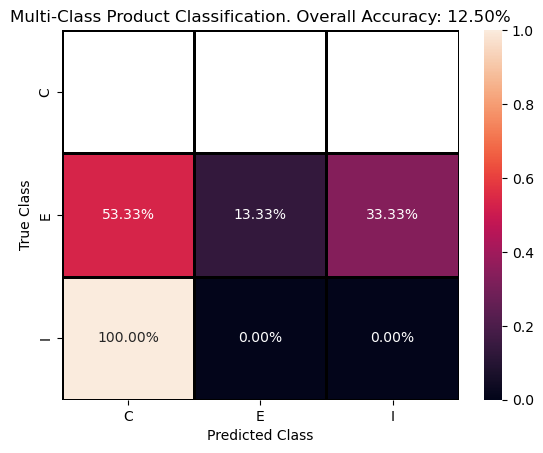

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+--------------+-------------------+-----------------+----------------------+------------------------+
| Prodcut_ID   | True Esci Label   | True Encoding   | Predicted Encoding   | Predicted Esci Label   |
|--------------+-------------------+-----------------+----------------------+------------------------|
+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------

Query ID: 43806


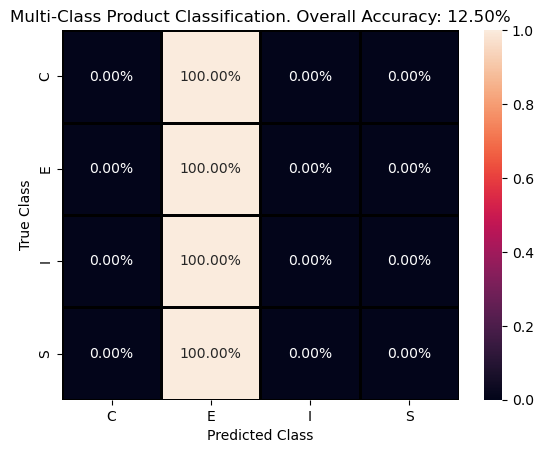

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
|  0 | B07MQD7WNB   | S                 |               3 |                    1 | E                      |
|  1 | B07NYB1CGY   | S                 |               3 |                    1 | E                      |
|  4 | B00N3OELPU   | S                 |               3 |                    1 | E                      |
|  6 | B06XMRQ68B   | S                 |               3 |                    1 | E                      |
|  9 | B077ZX9KJ7   | S                 |               3 |                    1 | E                      |
| 10 | B07796MBJ7   | S                 |

C:\Users\flash\AppData\Local\Temp\ipykernel_10780\917970735.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


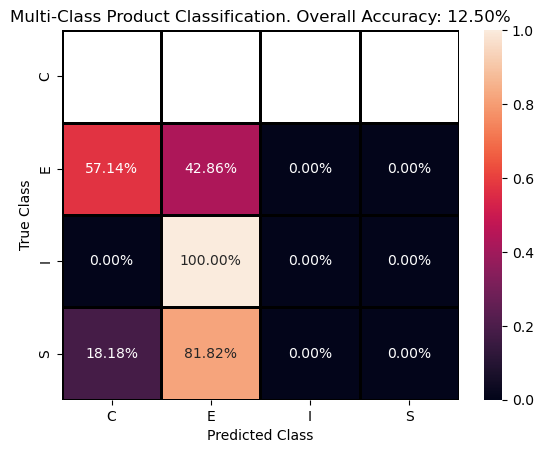

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
| 20 | B0094M2YL8   | S                 |               3 |                    1 | E                      |
| 19 | B0091X8FUE   | S                 |               3 |                    1 | E                      |
| 18 | B0091X21IQ   | S                 |               3 |                    1 | E                      |
| 17 | B004MPEFBE   | S                 |               3 |                    1 | E                      |
| 13 | B002RRWWQ4   | S                 |               3 |                    1 | E                      |
| 22 | B005UG542S   | S                 |

C:\Users\flash\AppData\Local\Temp\ipykernel_10780\917970735.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


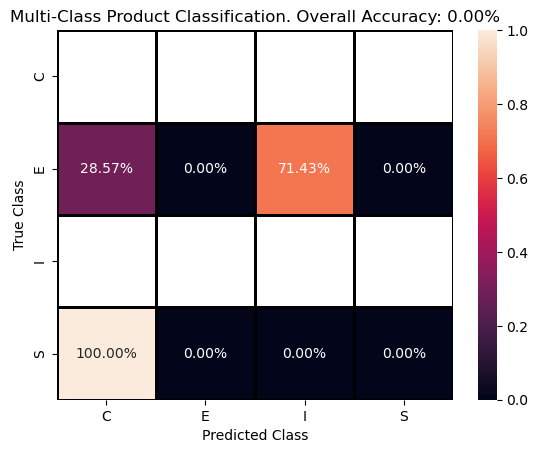

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
| 13 | B07XRHQ3SG   | S                 |               3 |                    0 | C                      |
| 15 | B07R8GR6L1   | S                 |               3 |                    0 | C                      |
+----+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------

Query ID: 101458


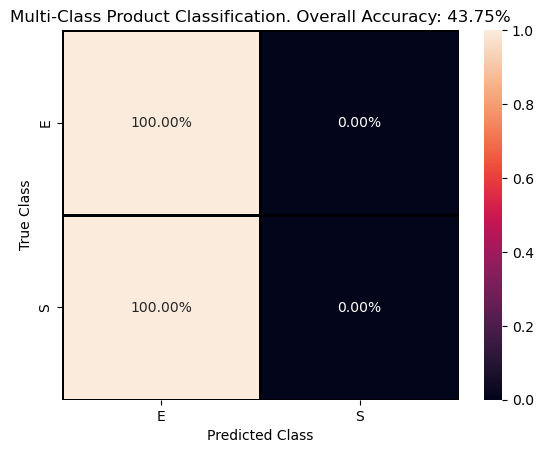

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
|  1 | B085MFXM3Q   | S                 |               3 |                    1 | E                      |
|  2 | B08CDQ52TB   | S                 |               3 |                    1 | E                      |
|  4 | B08QTTF2BZ   | S                 |               3 |                    1 | E                      |
|  8 | B095Y736PH   | S                 |               3 |                    1 | E                      |
|  9 | B07QNM91NQ   | S                 |               3 |                    1 | E                      |
| 10 | B07QDVLXNN   | S                 |

C:\Users\flash\AppData\Local\Temp\ipykernel_10780\917970735.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


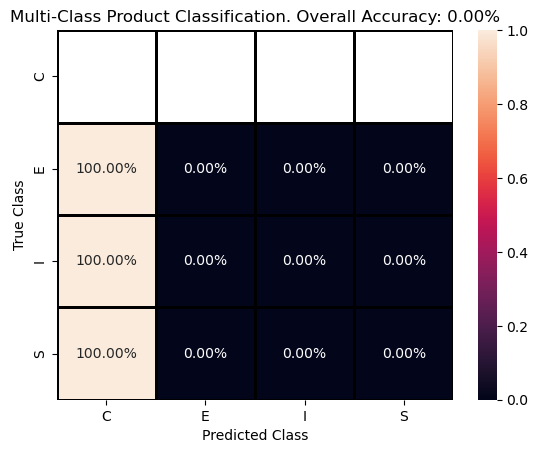

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
|  0 | B075ZPP65B   | S                 |               3 |                    0 | C                      |
|  3 | B07HK58CD3   | S                 |               3 |                    0 | C                      |
|  5 | B0822RGN5L   | S                 |               3 |                    0 | C                      |
|  6 | B07RXPZ5FR   | S                 |               3 |                    0 | C                      |
|  7 | B078SB8XT9   | S                 |               3 |                    0 | C                      |
|  9 | B07NC6FS7N   | S                 |

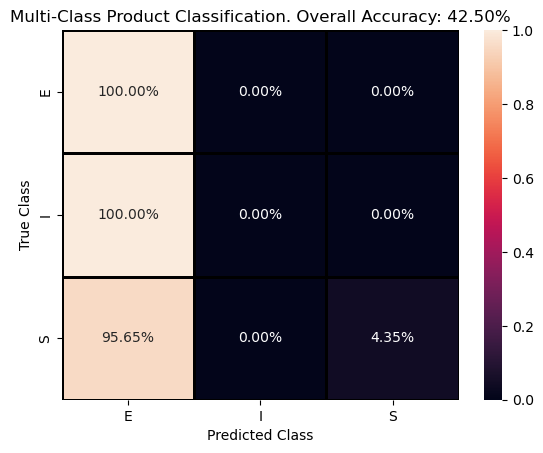

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
| 39 | B0992P2KFL   | S                 |               3 |                    3 | S                      |
| 17 | B098Q7DLJ6   | S                 |               3 |                    1 | E                      |
| 23 | B0796NC5YC   | S                 |               3 |                    1 | E                      |
|  2 | B00OJ714Q4   | S                 |               3 |                    1 | E                      |
|  5 | B01DBI025K   | S                 |               3 |                    1 | E                      |
|  7 | B079Z4942F   | S                 |

C:\Users\flash\AppData\Local\Temp\ipykernel_10780\917970735.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


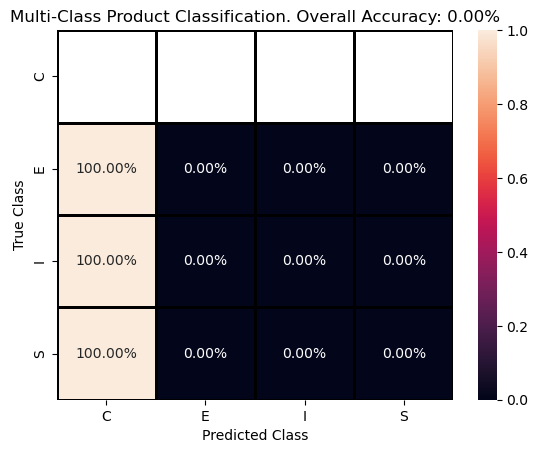

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
|  2 | B07YWMS21R   | S                 |               3 |                    0 | C                      |
+----+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------



In [10]:
from tabulate import tabulate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

query_ids = Large_Dataset_Test.query_id.unique()
random_query_ids = np.random.choice(query_ids, size = 10, replace = False)


for query_id in random_query_ids:
    query_id_mask = Large_Dataset_Test.loc[:, "query_id"] == query_id
    subset = Large_Dataset_Test.loc[query_id_mask, :]
    print(f"Query ID: {query_id}")
    Result_df = Model.Task(subset)
    accuracy = np.mean(Result_df.loc[:, "Predicted Esci Label"] == Result_df.loc[:, "True Esci Label"])
    cm = confusion_matrix(y_true = Result_df["True Encoding"].to_numpy().astype(int), y_pred = Result_df["Predicted Encoding"].to_numpy().astype(int))
    cm = cm / np.sum(cm, axis = 1)[:, None]
    labels = pd.DataFrame(np.concatenate((Result_df.loc[:, ("True Esci Label", "True Encoding")].to_numpy(), Result_df.loc[:, ("Predicted Esci Label", "Predicted Encoding")].to_numpy()), axis = 0)).drop_duplicates().sort_values(by = [1]).iloc[:, 0]
    
    fig = plt.figure()
    ax = fig.add_subplot()
    sns.heatmap(cm, ax = ax, xticklabels = labels, yticklabels = labels, fmt = ".2%", annot = True, linewidths = 1, linecolor = "black", vmin = 0, vmax = 1)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_title(f"Multi-Class Product Classification. Overall Accuracy: {accuracy:.2%}")
    plt.show()
    
    substitute_mask = Result_df["True Esci Label"] == "S"
    S_df = Result_df.loc[substitute_mask, :]
    S_df = S_df.sort_values(by = ["Predicted Encoding"], ascending = False)
    print("Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S")
    print(tabulate(S_df, headers='keys', tablefmt='psql'))
    print("\n---------------------\n")



In [11]:
# build premptive tree
# for every test_query:
## 1. finish tree and get neighbors
## 2. from teh neighbor ids find the true prodcut ids and titles
## 3. from the query id find the true query id and query
## 4. put them all together
## 5. print table



In [12]:
tensor_size = 32
products_test_embedded = pd.concat((Large_Dataset_Test.iloc[:, :6*tensor_size], Large_Dataset_Test.loc[:, ("product_id", "")]), axis = 1, ignore_index = True).drop_duplicates(subset = 6*tensor_size).reset_index(drop = True)
querys_test_embedded = pd.concat((Large_Dataset_Test.iloc[:, 6*tensor_size:7*tensor_size], Large_Dataset_Test.loc[:, ("query_id", "")]), axis = 1, ignore_index = True).drop_duplicates(subset = tensor_size).reset_index(drop = True)

# build the preemptive tree
# preempitve_Tree = Model.build_preemptive_distance_tree(products_test_embedded.iloc[:, :-1])
batch_size = 500
products_test_tower_embedded = Model.product_tower(torch.tensor(products_test_embedded.iloc[:batch_size, :-1].to_numpy(), dtype = torch.float32))
for i in tqdm(range(batch_size, products_test_embedded.shape[0] - batch_size, batch_size), desc = "running the product sentence embeddings through the product tower"):
    temp = Model.product_tower(torch.tensor(products_test_embedded.iloc[i:i+batch_size, :-1].to_numpy(), dtype = torch.float32))
    products_test_tower_embedded = torch.concatenate((products_test_tower_embedded, temp), axis = 0)
temp = Model.product_tower(torch.tensor(products_test_embedded.iloc[i+batch_size:, :-1].to_numpy(), dtype = torch.float32))
products_test_tower_embedded = torch.concatenate((products_test_tower_embedded, temp), axis = 0)

running the product sentence embeddings through the product tower: 100%|██████████| 1090/1090 [02:08<00:00,  8.45it/s]


In [13]:
same_random_ids = False
if not same_random_ids:
    query_ids = Large_Dataset_Test.query_id.unique()
    random_query_ids = np.random.choice(query_ids, size = 10, replace = False)

n_neighbours = 10
column_names = ["Query ID", "Query String"] + [f"Closest Neighbour {i+1}" for i in range(n_neighbours)]
nested_list = []
for query_id in random_query_ids:
    current_run_list = [int(query_id)]
    test_query_mask = querys_test_embedded.iloc[:, -1] == query_id
    test_query = querys_test_embedded.loc[test_query_mask, :]
    string_query = Queries.loc[Queries.query_id == query_id, "query"].iloc[0]
    current_run_list.append(string_query)
    test_query_tower_embedded = Model.query_tower(torch.tensor(test_query.iloc[:, :-1].to_numpy(), dtype = torch.float32))
    euclidean_distances = torch.sqrt(torch.sum(torch.square(products_test_tower_embedded - test_query_tower_embedded), axis = 1))
    top_10_neighbors = torch.argsort(euclidean_distances)[:n_neighbours]
    for implicit_neighbor_id in top_10_neighbors:
        actual_id = products_test_embedded.iloc[int(implicit_neighbor_id), -1]
        product_name = Products.loc[Products.product_id == actual_id, "product_title"].iloc[0]
        current_run_list.append(product_name)
    nested_list.append(current_run_list)

In [14]:
as_DF = pd.DataFrame(np.array(nested_list), columns = column_names)
as_DF

,Query ID,Query String,Closest Neighbour 1,Closest Neighbour 2,Closest Neighbour 3,Closest Neighbour 4,Closest Neighbour 5,Closest Neighbour 6,Closest Neighbour 7,Closest Neighbour 8,Closest Neighbour 9,Closest Neighbour 10
0,101087,teal tutu girls,Korea War Veteran Baseball Style Embroidered H...,Night,Holy Bible: Contemporary English Version,Two Left Feet womens Two Left Feet Women's Pri...,Columbia Big Boy's Rugged Ridge Faux Sherpa Li...,Mippo Womens Workout Tops Athletic Yoga Tops f...,Organic Fresh Frozen Camel Milk - Fresh Flavor...,Columbia Women's Standard Chatfield Hill Jacke...,Romwe Women's Off The Shoulder Ruffle Casual L...,Cole Haan Women's Taffeta Down Double Breasted...
1,39398,fake window wall sticker,1PC Anti-cut Gloves Safety Cut Proof Stab Resi...,ps4 switch変換アダプタコントローラー 変換アダプター 対応Nintendo Swi...,カケラ,岳 -ガク-,【WHOMEE フーミー】スクリューブラシ アイブロウ・まつ毛用,8MILELAKE 8セット ツールフック ダブルフック 強力 壁掛け 物掛け フック ガレ...,売れるパッケージデザイン 150の鉄則,プール ビニールプール 修理用パッチ 6枚入り インテックス INTEX プール修理 リペアパッチ,繋がった糸,ブルーレイケース
2,50232,hepa h13 filter,"Nasa Circle Lhc Capucha, Gris (Grey Gry), Larg...",La Libertad y La Ley: 9 (Nueva Biblioteca de l...,Sagrada Biblia Cee cremallera: Versión oficial...,"Nasa Circle Logo Capucha, Gris (Grey Marl SPO)...",Nomeca Bolsas de Almacenamiento de Alimentos R...,UNO de 50 Salud BLINDADA,Confidencias de medianoche [DVD],La miseria del intervencionismo: 1929-2008 (Bi...,《新入試対応》 大学入試 全レベル問題集 化学 1 基礎レベル 新装版,Aishnuwéhrta. Las ideas de deidad en la religi...
3,102246,the north face cap futurelight,Korea War Veteran Baseball Style Embroidered H...,Night,Fee Brothers Rose Flower Water - 5 oz,Holy Bible: Contemporary English Version,21 Days Together,Bounty Milk Chocolate Case of 24,CITTA手帳2020年3月始まりピーコックブルー,梅ぼし純 24粒【4個セット】,月刊Hanada2020年6月号 [雑誌],Fee Brothers West Indian Orange Bitters 5oz
4,114509,xonar u5,Muerte Y Vida de Las Grandes Ciudades (Narraci...,LENGUA 6 DE PRIMARIA SABER HACER CONTIGO,相手も自分も大切にするコミュニケーション+社会学,Crônicas de VIA TRIA 2: Jardins em Abundância ...,Friday Night Massacre [Explicit],高等学校新学習指導要領の展開 保健体育科編,Real Analysis: A Long-Form Mathematics Textboo...,Los secretos eternos de la salud: medicina de ...,Written in the Stars (English Edition),奈良美智 YOSHITOMO NARA SELF-SELECTED WORKS PAINTINGS
5,73564,nike headband cooling,【第2類医薬品】プチウナコーワ(プチピンク) 12mL,[トクホ] [訳あり(メーカー過剰在庫)] ヘルシア緑茶 うまみ贅沢仕立て 1L ×12本,【第2類医薬品】新ウナコーワクール 55mL,Korea War Veteran Baseball Style Embroidered H...,[トクホ] [訳あり(メーカー過剰在庫)] ヘルシア緑茶 うまみ贅沢仕立て 500ml×24本,サントリー 朝摘みオレンジ&南アルプスの天然水(冷凍兼用) 540ml×24本,芳醇ぶどう ＆ サントリー 天然水 冷凍兼用 540ml ×24本,ウルラボディソープ 200ｍｌ 日本製 デリケートゾーンソープ 弱酸性,アリサン ムング豆 500g,【第2類医薬品】ドルマイシン軟膏 12g
6,69133,milla jovovich,OH NO!,つり情報2020年5月15日号,CITTA手帳2020年3月始まりピーコックブルー,月刊Hanada2020年6月号 [雑誌],月刊Hanada2020年5月号 [雑誌],NHKウイークリーステラ 2019年 11/1号,つり情報2020年1月1日号,マルカワガム 売筋4点食べ比べセット,Dolce & Gabbana Light Blue Eau de Toilette Vap...,資生堂 シュエトゥールズ ブロー&アイラッシュブラシ
7,84728,puzzles 100 piezas niños,Christmas,Red Robin #26,Making Movies,28 Days,Llama Llama Loves Camping,Xitek KA-S2MCB 2X New Black Carbon Fiber K Fro...,Camping Hair Don't Care Women's Cotton Vintage...,Graceprom Women's Beaded Crystal Quinceanera D...,A Strangeness in My Mind: A novel (Vintage Int...,The Fire Next Time
8,22118,campana decorativa isla,Donde El Corazon Te Lleve,Fire HD 8 Plus タブレット スレート (8インチHDディスプレイ) 32GB,Fire HD 8 タブレット ホワイト (8インチHDディスプレイ) 32GB,Fire HD 8 Plus タブレット スレート (8インチHDディスプレイ) 64GB,【第2類医薬品】プチウナコーワ(プチピンク) 12mL,"Fire HD 10 Tablet (10.1"" 1080p full HD display...","Fire HD 10 Tablet (10.1"" 1080p full HD display...",第9世代 Fire HD10 タブレット ブルー (10インチHDディスプレイ) 64GB,Hoover Sprint Evo SE61 Aspiradora sin Bolsa de...,"All-new Fire HD 10 tablet, 10.1"", 1080p Full H..."
9,17701,bmi calculator,Windows 10 Pro OEM - 64 Bit Version | English ...,RUFFNECK NHL Home Team Jersey Scarf -Columbus ...,"KONKY - PS4 Controller Charging Dock Stand, US...","Disguise Men's The Incredibles Gloves, Black, ...","Cricut Explore Air 2, Matte Black",COOFANDY Mens Slim Fit Blazer Casual Sports Ja...,Mkeke iPhone SE 2020 ケース、